# Metriky regresních modelů – Cvičení 1 (Calculating Regression Model Metrics)
**Dataset:** Předzpracovaná data nemovitostí King County (`kc_house_data_preprocessed.csv`)  
**Cíl cvičení:** Výpočet, porovnání a expertní interpretace regresních metrik ($R^2$, Adjusted $R^2$, $\text{MAE}$, $\text{MSE}$, $\text{RMSE}$) pro trénovací i testovací sadu.

---
### Zadání cvičení:
1. Načíst předzpracovaný dataset `kc_house_data_preprocessed.csv` uložený z Cvičení 1.
2. Importovat všechny potřebné metody související s regresními metrikami.
3. Spustit postupně buňky kódu: import, načtení dat, trénování a predikce lineární regrese.
4. Provést predikci na trénovací sadě (`X_train`) a výsledek uložit do proměnné `y_pred_train`.
5. Pro trénovací i testovací data spočítat metriky: $R^2$, korigovaný $R^2$, $\text{MAE}$, $\text{MSE}$ a $\text{RMSE}$ a zobrazit je v přehledné čitelné formě.

## Krok 1: Import knihoven a konfigurace

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor

# Cesty
base_dir = Path('.').resolve()
data_dir = base_dir / 'data'
plots_dir = base_dir / 'plots'
data_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

## Krok 2: Načtení předzpracovaného datasetu (`kc_house_data_preprocessed.csv`)

In [2]:
csv_path = data_dir / 'kc_house_data_preprocessed.csv'
housing_df = pd.read_csv(csv_path)
print(f"Rozměry datasetu: {housing_df.shape[0]} řádků, {housing_df.shape[1]} sloupců.")
housing_df.head()

Rozměry datasetu: 21553 řádků, 19 sloupců.


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Krok 3: Rozdělení dat na Train a Test sadu (80 / 20)

In [3]:
X = housing_df.drop(columns=['price'])
y = housing_df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

n_train, k_features = X_train.shape
n_test = X_test.shape[0]

print(f"Trénovací data (Train): {n_train} řádků, {k_features} příznaků.")
print(f"Testovací data  (Test):  {n_test} řádků, {k_features} příznaků.")

Trénovací data (Train): 17242 řádků, 18 příznaků.
Testovací data  (Test):  4311 řádků, 18 příznaků.


## Krok 4: Trénování modelu LinearRegression a generování predikcí

In [4]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predikce na trénovací sadě (y_pred_train dle zadání)
y_pred_train = lin_reg.predict(X_train)

# Predikce na testovací sadě (y_pred_test)
y_pred_test = lin_reg.predict(X_test)

print(f"Predikce vygenerovány: y_pred_train ({len(y_pred_train)}), y_pred_test ({len(y_pred_test)}).")

Predikce vygenerovány: y_pred_train (17242), y_pred_test (4311).


## Krok 5: Implementace funkce pro Korigovaný koeficient determinace (Adjusted $R^2$)

Vzorec korigovaného $R^2$:
$$\text{Adj } R^2 = 1 - \frac{(1 - R^2)(n - 1)}{n - k - 1}$$
kde $n$ je počet pozorování a $k$ je počet predikčních příznaků.

In [5]:
def adjusted_r2_score(r2: float, n: int, k: int) -> float:
    return 1.0 - ((1.0 - r2) * (n - 1) / (n - k - 1))

## Krok 6: Výpočet všech 5 povinných metrik pro Train i Test

In [6]:
def get_metrics(y_true, y_pred, n, k, name):
    r2 = r2_score(y_true, y_pred)
    adj_r2 = adjusted_r2_score(r2, n, k)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {
        'Dataset': name,
        'R2': r2,
        'Adjusted R2': adj_r2,
        'MAE ($)': mae,
        'MSE ($^2)': mse,
        'RMSE ($)': rmse
    }

metrics_train = get_metrics(y_train, y_pred_train, n_train, k_features, 'Trénovací (Train)')
metrics_test = get_metrics(y_test, y_pred_test, n_test, k_features, 'Testovací (Test)')

results_df = pd.DataFrame([metrics_train, metrics_test])

# Čitelná formátovaná tabulka
disp_df = results_df.copy()
disp_df['R2'] = disp_df['R2'].apply(lambda x: f"{x:.4f}")
disp_df['Adjusted R2'] = disp_df['Adjusted R2'].apply(lambda x: f"{x:.4f}")
disp_df['MAE ($)'] = disp_df['MAE ($)'].apply(lambda x: f"${x:,.2f}")
disp_df['MSE ($^2)'] = disp_df['MSE ($^2)'].apply(lambda x: f"{x:,.0f}")
disp_df['RMSE ($)'] = disp_df['RMSE ($)'].apply(lambda x: f"${x:,.2f}")
disp_df

,Dataset,R2,Adjusted R2,MAE ($),MSE ($^2),RMSE ($)
0,Trénovací (Train),0.7077,0.7074,"$118,250.67","32,003,674,467","$178,895.71"
1,Testovací (Test),0.7118,0.7106,"$117,241.66","30,737,373,833","$175,320.77"


## Krok 7: Expertní interpretace metrik (09/2026)

### 1. Stabilita Train vs Test (Diagnostika přeučení / biasu)
- $R^2$ Train: **0.7077** vs $R^2$ Test: **0.7118**
- MAE Train: **118 251 USD** vs MAE Test: **117 242 USD**
> **Závěr:** Model má nulový overfitting. Chová se na testovací sadě stejně stabilně jako na trénovací. Hlavním limitem je vysoký bias lineární přímky (underfitting vůči složité realitě trhu).

### 2. Proč se Adjusted $R^2$ téměř neliší od $R^2$?
Vzorec penalizuje počet parametrů faktorem $\frac{n - 1}{n - k - 1}$.  
Při $n = 17 242$ a $k = 18$ je tento faktor roven $\frac{17241}{17223} = 1{,}00104$. Proto je rozdíl pouze 0 USD{,}0012$. Adjusted $R^2$ je podstatný při malých datech (např. $n=50, k=15$), u moderních velkých dat se téměř shoduje s klasickým $R^2$.

### 3. Co znamená poměr $\frac{\text{RMSE}}{\text{MAE}} = 1{,}495$?
U Gaussovského normálního rozdělení chyb je teoretický poměr $\frac{\text{RMSE}}{\text{MAE}} = \sqrt{\frac{\pi}{2}} \approx 1{,}253$.  
Hodnota **1.495** dokazuje přítomnost **těžkých chybových chvostů** (extrémní multimilionové odchylky u luxusních domů, které kvadratické MSE masivně penalizuje).

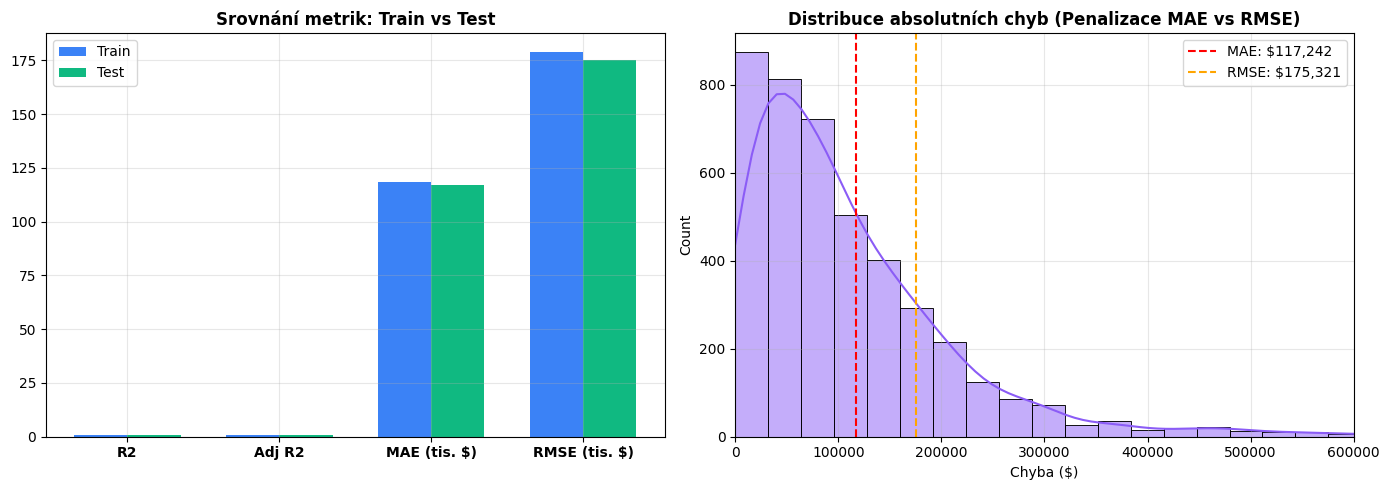

In [7]:
# Grafické znázornění metrik a distribuce chyb
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Srovnání Train vs Test
metric_names = ['R2', 'Adj R2', 'MAE (tis. $)', 'RMSE (tis. $)']
tr_vals = [metrics_train['R2'], metrics_train['Adjusted R2'], metrics_train['MAE ($)']/1000, metrics_train['RMSE ($)']/1000]
te_vals = [metrics_test['R2'], metrics_test['Adjusted R2'], metrics_test['MAE ($)']/1000, metrics_test['RMSE ($)']/1000]

x = np.arange(len(metric_names))
w = 0.35

ax1.bar(x - w/2, tr_vals, w, label='Train', color='#3b82f6')
ax1.bar(x + w/2, te_vals, w, label='Test', color='#10b981')
ax1.set_xticks(x)
ax1.set_xticklabels(metric_names, fontweight='bold')
ax1.set_title('Srovnání metrik: Train vs Test', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Distribuce chyb
abs_errors = np.abs(y_test - y_pred_test)
sns.histplot(abs_errors, bins=50, kde=True, ax=ax2, color='#8b5cf6')
ax2.axvline(metrics_test['MAE ($)'], color='red', linestyle='--', label=f"MAE: ${metrics_test['MAE ($)']:,.0f}")
ax2.axvline(metrics_test['RMSE ($)'], color='orange', linestyle='--', label=f"RMSE: ${metrics_test['RMSE ($)']:,.0f}")
ax2.set_title('Distribuce absolutních chyb (Penalizace MAE vs RMSE)', fontweight='bold')
ax2.set_xlabel('Chyba ($)')
ax2.set_xlim(0, 600000)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Krok 8: Porovnání chování metrik napříč architekturami modelů

In [8]:
# Log-OLS
log_model = TransformedTargetRegressor(
    regressor=Pipeline([('scaler', StandardScaler()), ('reg', LinearRegression())]),
    func=np.log1p, inverse_func=np.expm1
).fit(X_train, y_train)
m_log = get_metrics(y_test, log_model.predict(X_test), n_test, k_features, '2. Log-Transformed OLS')

# Gradient Boosting
hgb = HistGradientBoostingRegressor(random_state=42).fit(X_train, y_train)
m_hgb = get_metrics(y_test, hgb.predict(X_test), n_test, k_features, '3. Gradient Boosting (HGB)')

m_ols = metrics_test.copy()
m_ols['Dataset'] = '1. Základní OLS'

models_comp = pd.DataFrame([m_ols, m_log, m_hgb])
models_comp['R2'] = models_comp['R2'].apply(lambda v: f"{v:.4f}")
models_comp['Adjusted R2'] = models_comp['Adjusted R2'].apply(lambda v: f"{v:.4f}")
models_comp['MAE ($)'] = models_comp['MAE ($)'].apply(lambda v: f"${v:,.0f}")
models_comp['RMSE ($)'] = models_comp['RMSE ($)'].apply(lambda v: f"${v:,.0f}")
models_comp.drop(columns=['MSE ($^2)'])

,Dataset,R2,Adjusted R2,MAE ($),RMSE ($)
0,1. Základní OLS,0.7118,0.7106,"$117,242","$175,321"
1,2. Log-Transformed OLS,0.7152,0.7140,"$107,843","$174,288"
2,3. Gradient Boosting (HGB),0.9019,0.9015,"$64,575","$102,306"
